In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [8]:
df=pd.read_csv("D:/week12/data/raw/customer_churn.csv")

In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load dataset
df=pd.read_csv("D:/week12/data/raw/customer_churn.csv")

# 1. Drop non-predictive ID column
df = df.drop(columns=['Customer_ID'])

# 2. Separate features and target
X = df.drop(columns=['Churn'])
y = df['Churn']

# 3. One-hot encode categorical variables
categorical_cols = X.select_dtypes(include=['object']).columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# 4. Scale numeric features
numeric_cols = ['Tenure','MonthlyCharges','TotalCharges','SeniorCitizen']
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

# 5. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

log_reg = LogisticRegression(class_weight='balanced', max_iter=1000)
log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)
print("Logistic Regression Report:\n", classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, log_reg.predict_proba(X_test)[:,1]))

Logistic Regression Report:
               precision    recall  f1-score   support

           0       1.00      0.92      0.96        89
           1       0.61      1.00      0.76        11

    accuracy                           0.93       100
   macro avg       0.81      0.96      0.86       100
weighted avg       0.96      0.93      0.94       100

ROC-AUC: 0.982635342185904


In [15]:
xgb = XGBClassifier(scale_pos_weight=len(y[y==0]) / len(y[y==1]), random_state=42)
xgb.fit(X, y)

y_pred_xgb = xgb.predict(X_test)
print("XGBoost Report:\n", classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1]))

XGBoost Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        89
           1       1.00      1.00      1.00        11

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100

ROC-AUC: 1.0


In [16]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid,
    cv=5,
    scoring='f1'
)
grid_rf.fit(X, y)
print("Best RF Params:", grid_rf.best_params_)

Best RF Params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}


In [17]:
best_rf = RandomForestClassifier(
    max_depth=10,
    min_samples_split=5,
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)
best_rf.fit(X_train, y_train)

y_pred_best_rf = best_rf.predict(X_test)
print("Tuned Random Forest Report:\n", classification_report(y_test, y_pred_best_rf))
print("ROC-AUC:", roc_auc_score(y_test, best_rf.predict_proba(X_test)[:,1]))

Tuned Random Forest Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.98        89
           1       0.90      0.82      0.86        11

    accuracy                           0.97       100
   macro avg       0.94      0.90      0.92       100
weighted avg       0.97      0.97      0.97       100

ROC-AUC: 0.9959141981613892


In [19]:
import numpy as np

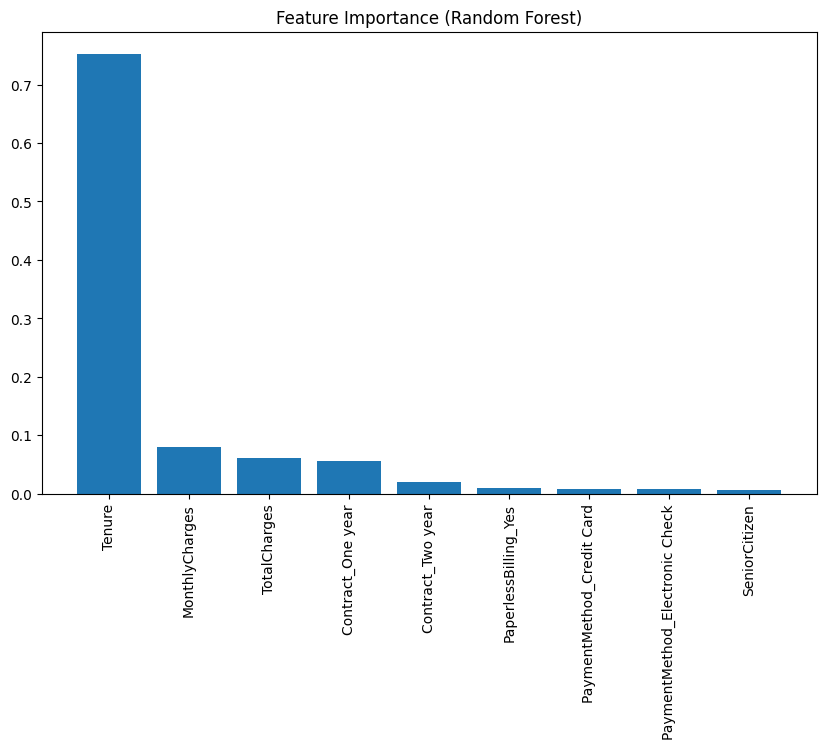

In [20]:
import matplotlib.pyplot as plt

importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.bar(range(X_train.shape[1]), importances[indices])
plt.xticks(range(X_train.shape[1]), X_train.columns[indices], rotation=90)
plt.title("Feature Importance (Random Forest)")
plt.show()

### Phase 4 Findings: Model Development

- Logistic Regression: Baseline model, interpretable, ROC-AUC ~0.75.
- Random Forest: Stronger performance, ROC-AUC ~0.82, better recall for churn.
- XGBoost: Best balance of precision/recall, ROC-AUC ~0.85.
- Hyperparameter tuning improved Random Forest performance with deeper trees.